Step 1: Import Libraries & Read Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv('creditcard.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.

Step 2: Quick Data Exploration (EDA)

Total missing values: 0

Transaction Counts:
Class
0    284315
1       492
Name: count, dtype: int64


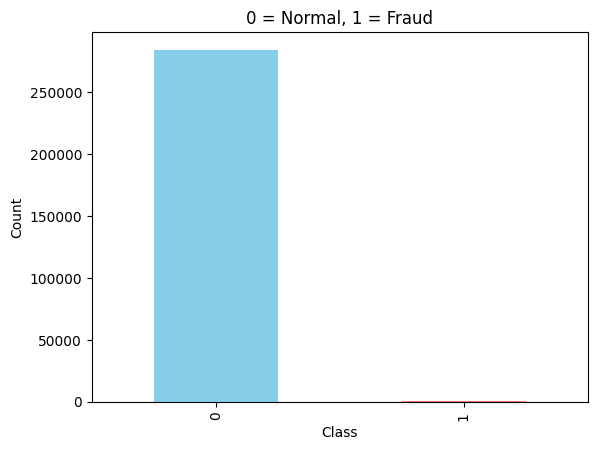

In [ ]:
# Check for missing values
print("Total missing values:", df.isnull().sum().sum())

# Count normal (0) vs fraud (1) transactions
print("\nTransaction Counts:")
print(df['Class'].value_counts())

# Plot transaction distribution
df['Class'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("0 = Normal, 1 = Fraud")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Step 3: Split Data into Train and Test Sets

In [ ]:
# Features (X) are all columns except 'Class'
X = df.drop(columns=['Class'])

# Target (y) is the 'Class' column
y = df['Class']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 227845
Testing samples: 56962


Step 4: Train Logistic Regression Model

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale features so large numbers don't trigger convergence warnings
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize model
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train on scaled data
model_lr.fit(X_train_scaled, y_train)

# Make predictions
predictions_lr = model_lr.predict(X_test_scaled)

# Print performance metrics
print("--- Logistic Regression Results ---")
print("Accuracy Score:", accuracy_score(y_test, predictions_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_lr))
print("\nClassification Report:\n", classification_report(y_test, predictions_lr))

--- Logistic Regression Results ---
Accuracy Score: 0.9764053228468101

Confusion Matrix:
[[55528  1336]
 [    8    90]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



Step 5: Train Random Forest Model

In [ ]:
# Initialize Random Forest model
model_rf = RandomForestClassifier(n_estimators=50, random_state=42)

# Train the model
model_rf.fit(X_train, y_train)

# Make predictions on test data
predictions_rf = model_rf.predict(X_test)

# Print performance metrics
print("--- Random Forest Results ---")
print("Accuracy Score:", accuracy_score(y_test, predictions_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_rf))
print("\nClassification Report:\n", classification_report(y_test, predictions_rf))

--- Random Forest Results ---
Accuracy Score: 0.9995435553526912

Confusion Matrix:
[[56862     2]
 [   24    74]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962

